# The Dolphin of MoA

I was experimenting with UMAP and going to publish my reproduction of this figure. However, I came across this familar looking shape and had to publish as a standalone notebook 😆 

(Note that you might not be able to reproduce this since I did not set a seed)

In [2]:
# install RAPIDS
import sys
!cp ../input/rapids/rapids.0.15.0 /opt/conda/envs/rapids.tar.gz
!cd /opt/conda/envs/ && tar -xzvf rapids.tar.gz > /dev/null
sys.path = ["/opt/conda/envs/rapids/lib/python3.7/site-packages"] + sys.path
sys.path = ["/opt/conda/envs/rapids/lib/python3.7"] + sys.path
sys.path = ["/opt/conda/envs/rapids/lib"] + sys.path 
!cp /opt/conda/envs/rapids/lib/libxgboost.so /opt/conda/lib/

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cuml import UMAP

In [4]:
train_features = pd.read_csv('../input/lish-moa/train_features.csv')
train_targets = pd.read_csv('../input/lish-moa/train_targets_scored.csv')
train_targets_ns = pd.read_csv('../input/lish-moa/train_targets_nonscored.csv')
test_features = pd.read_csv('../input/lish-moa/test_features.csv')
sample_submission = pd.read_csv('../input/lish-moa/sample_submission.csv')

In [19]:
all_features = pd.concat([train_features, test_features])
gene_features = all_features[[c for c in all_features.columns if 'g-' in c]].values
cell_features = all_features[[c for c in all_features.columns if 'c-' in c]].values

umap = UMAP()
gene_features_umap = umap.fit_transform(gene_features)
cell_features_umap = umap.fit_transform(cell_features)
all_features_umap = umap.fit_transform(np.hstack([gene_features, cell_features]))

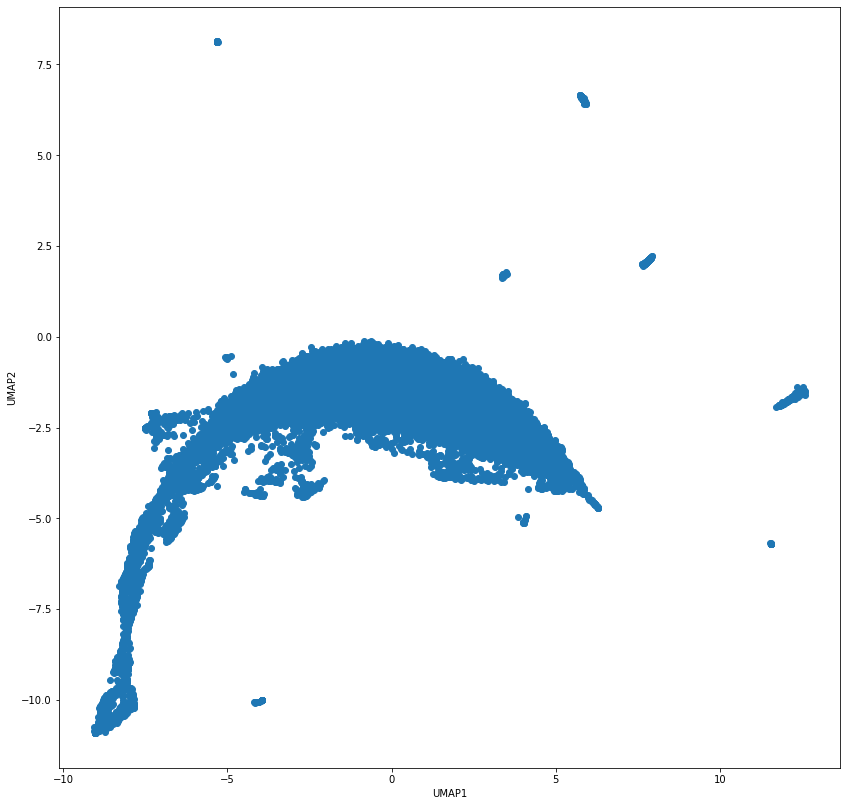

In [22]:
x, y = cell_features_umap.T
fig, ax = plt.subplots(1, 1, figsize=(14, 14))
ax.scatter(x, y)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
plt.show()

![](https://i.imgur.com/WIh6HZU.jpg)

# Coincidence? I think not